<a href="https://colab.research.google.com/github/LaRocaDeKiwi/MLE/blob/Conv1D/presentacion%20parte1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Concepto Fundamental**

Una capa de convolución 1D es una operación que aplica filtros deslizantes sobre secuencias unidimensionales, extrayendo patrones locales mediante el producto punto entre el filtro y segmentos de la entrada.

In [ ]:
from keras.layers import Conv1D
# En frameworks como TensorFlow/Keras
conv_layer = Conv1D(
    filters=32,           # Número de kernels diferentes
    kernel_size=3,        # Tamaño de cada kernel
    strides=1,           # Paso de deslizamiento
    padding='same',      # 'same' o 'valid'
    activation='relu'    # Función de activación
)

**Formato de entrada**

(batch_size, steps, input_channels)

Parametros

*   filters: int, la dimension del espacio de salida (# de filtros en la convolucion)
*   kernel_size: int, especifica el tamaño de la ventana de la convolucion
*   strides: int, Especifica el tamaño del deslizamiento. strides > 1 is incompatible with dilation_rate > 1.
*   padding: string, "valid", "same" or "causal". "valid" no hay relleno. "same" rellenadp de igual forma arriba/abajo y/o derecha/izquierda de la entrada. "causal" resulta en causal(dilatado) convoluciones, e.g. output[t] no depende de input[t+1:]
*   data_format : cadena, o bien "channels_last"o "channels_first". El orden de las dimensiones en las entradas. "channels_last"corresponde a las entradas con forma (batch, steps, features)mientras que "channels_first"corresponde a las entradas con forma (batch, features, steps).
*   dilation_rate:  int, especifica el ratio de dilatacion
*   activation: 	funcion de activacion.
*   use_bias : bool, si True, se agregará sesgo a la salida.

In [ ]:
!pip install matplotlib numpy tensorflow

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.models import Sequential

print("✅ Librerías importadas correctamente")
print(f"TensorFlow version: {tf.__version__}")

✅ Librerías importadas correctamente
TensorFlow version: 2.19.0


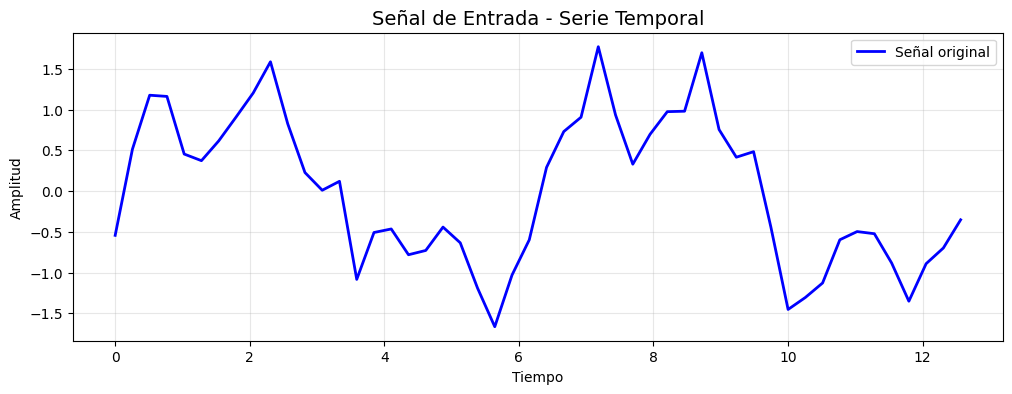

🔹 Forma de la señal: (1, 50, 1)
🔹 Valores (primeros 5): [-0.54323648  0.5137174   1.17649681  1.16178011  0.45451129]


In [ ]:
# 🎯 CREAR SEÑAL DE PRUEBA
def crear_senal_ejemplo():
    # Señal sintética con patrones específicos
    tiempo = np.linspace(0, 4*np.pi, 50)
    señal = np.sin(tiempo) + 0.5 * np.sin(3*tiempo) + 0.3 * np.random.randn(50)

    plt.figure(figsize=(12, 4))
    plt.plot(tiempo, señal, 'b-', linewidth=2, label='Señal original')
    plt.title('Señal de Entrada - Serie Temporal', fontsize=14)
    plt.xlabel('Tiempo')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return señal.reshape(1, -1, 1)  # Formato: (batch, steps, features)

señal_input = crear_senal_ejemplo()
print(f"🔹 Forma de la señal: {señal_input.shape}")
print(f"🔹 Valores (primeros 5): {señal_input[0, :5, 0].flatten()}")

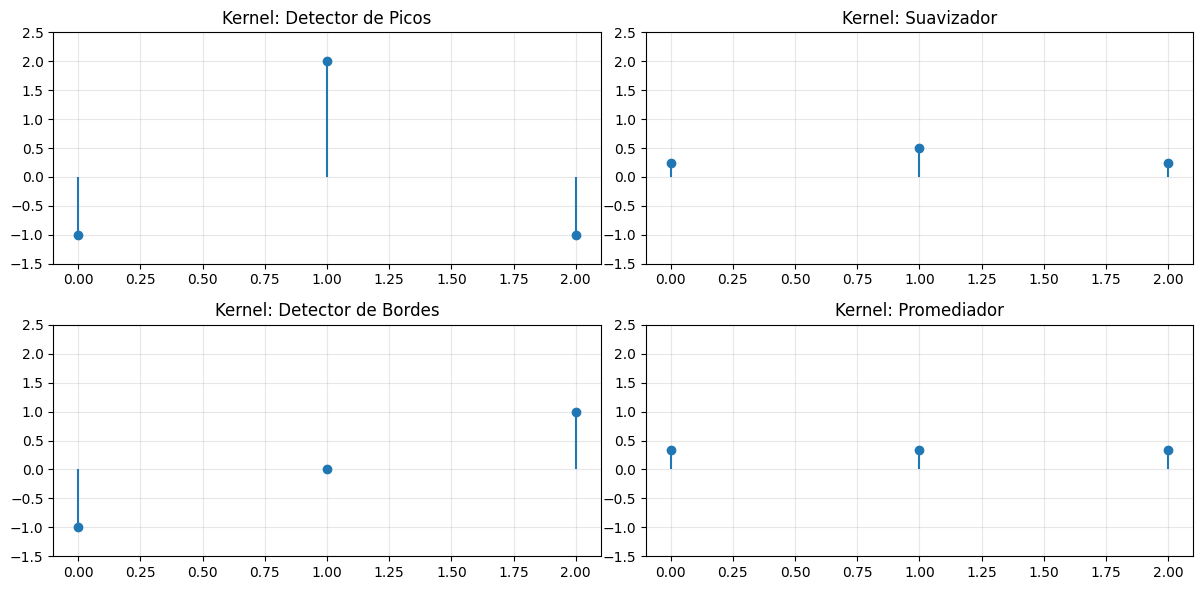

In [ ]:
# 🔧 KERNELS/FILTROS DE EJEMPLO
def crear_kernels_explicativos():
    kernels = {
        "Detector de Picos": np.array([-1, 2, -1]),
        "Suavizador": np.array([0.25, 0.5, 0.25]),
        "Detector de Bordes": np.array([-1, 0, 1]),
        "Promediador": np.array([0.33, 0.33, 0.33])
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    axes = axes.flatten()

    for i, (nombre, kernel) in enumerate(kernels.items()):
        axes[i].stem(kernel, basefmt=" ")
        axes[i].set_title(f'Kernel: {nombre}')
        axes[i].set_ylim(-1.5, 2.5)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return kernels

kernels = crear_kernels_explicativos()

In [ ]:
# 🎪 CONVOLUCIÓN MANUAL - PASO A PASO
def convolucion_manual_detallada(señal, kernel):
    señal_flat = señal.flatten()
    kernel_flat = kernel.flatten()
    kernel_size = len(kernel_flat)
    señal_size = len(señal_flat)

    print("=" * 70)
    print("CONVOLUCIÓN MANUAL - PASO A PASO")
    print("=" * 70)
    print(f"Señal: {señal_flat}")
    print(f"Kernel: {kernel_flat}")
    print(f"Tamaño señal: {señal_size}, Tamaño kernel: {kernel_size}")
    print()

    resultado = []

    for i in range(señal_size - kernel_size + 1):
        # Extraer ventana actual
        ventana = señal_flat[i:i + kernel_size]

        # Calcular producto punto
        calculo = np.dot(ventana, kernel_flat)
        resultado.append(calculo)

        # Mostrar cálculo detallado
        print(f"Paso {i+1}:")
        print(f"  Ventana: {ventana}")
        print(f"  Cálculo: {ventana} · {kernel_flat} = {calculo}")
        print(f"  Posición resultado[{i}] = {calculo}")
        print("-" * 40)

    return np.array(resultado)

# Probar con kernel detector de bordes
kernel_bordes = np.array([-1, 0, 1])
resultado_manual = convolucion_manual_detallada(señal_input[0, :, 0], kernel_bordes)

print(f"🔹 Resultado final: {resultado_manual}")

CONVOLUCIÓN MANUAL - PASO A PASO
Señal: [-0.54323648  0.5137174   1.17649681  1.16178011  0.45451129  0.37323066
  0.6157574   0.90665999  1.20395883  1.58689649  0.82648756  0.22734571
  0.01024847  0.12002602 -1.08390467 -0.50835861 -0.46490313 -0.78126253
 -0.72862827 -0.44192184 -0.63497981 -1.18980389 -1.66466338 -1.03057665
 -0.59802163  0.29034855  0.73049969  0.90663269  1.77168139  0.93384117
  0.32999534  0.69665843  0.97480029  0.98021624  1.69785911  0.75502233
  0.41564584  0.48355063 -0.43921323 -1.45276763 -1.30592505 -1.12767381
 -0.59748579 -0.49688615 -0.52323616 -0.8822787  -1.35155113 -0.89122876
 -0.69829068 -0.3524416 ]
Kernel: [-1  0  1]
Tamaño señal: 50, Tamaño kernel: 3

Paso 1:
  Ventana: [-0.54323648  0.5137174   1.17649681]
  Cálculo: [-0.54323648  0.5137174   1.17649681] · [-1  0  1] = 1.7197332923523065
  Posición resultado[0] = 1.7197332923523065
----------------------------------------
Paso 2:
  Ventana: [0.5137174  1.17649681 1.16178011]
  Cálculo: [0.5